In [12]:
# CELL: Imports and utilities
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import math, os, json, random
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from collections import Counter
# set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [13]:
# CELL: Load model & tokenizer
MODEL_NAME = "gpt2"   # "gpt2-medium" if GPU and you want stronger results
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
model.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [14]:
# CELL: Generation helper
def generate_text(prompt, max_length=100, temperature=1.0, top_k=0, top_p=0.0, do_sample=True, num_return_sequences=1):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output_ids = model.generate(
        **inputs,
        max_length=max_length,
        temperature=temperature,
        top_k=top_k if top_k>0 else None,
        top_p=top_p if top_p>0 else None,
        do_sample=do_sample,
        num_return_sequences=num_return_sequences,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    outputs = [tokenizer.decode(g, skip_special_tokens=True, clean_up_tokenization_spaces=True) for g in output_ids]
    return outputs


In [15]:
# CELL: Perplexity computation (batch-friendly)
def compute_perplexity(text):
    encodings = tokenizer(text, return_tensors="pt", truncation=False)
    max_length = model.config.n_positions
    stride = 512
    nlls = []
    input_ids = encodings.input_ids.to(device)
    seq_len = input_ids.size(1)
    # sliding window to handle long text
    for i in range(0, seq_len, stride):
        begin_loc = max(i + stride - max_length, 0)
        end_loc = min(i + stride, seq_len)
        input_ids_slice = input_ids[:, begin_loc:end_loc]
        target_ids = input_ids_slice.clone()
        with torch.no_grad():
            outputs = model(input_ids_slice, labels=target_ids)
            neg_log_likelihood = outputs.loss * (end_loc - begin_loc)
        nlls.append(neg_log_likelihood)
    ppl = torch.exp(torch.stack(nlls).sum() / seq_len).item()
    return ppl


In [16]:
# CELL: Diversity metrics: distinct-n and repetition rate
def distinct_n(texts, n=1):
    tokens = []
    for t in texts:
        tokens += tokenizer.tokenize(t)
    if len(tokens) == 0:
        return 0.0
    ngrams = zip(*[tokens[i:] for i in range(n)])
    unique = set(ngrams)
    return len(unique) / max(1, len(list(ngrams)))

def repetition_rate(text):
    toks = tokenizer.tokenize(" ".join(text))
    c = Counter(toks)
    repeated = sum(v-1 for v in c.values() if v>1)
    return repeated / max(1, len(toks))


In [17]:
prompts = {
    "tech": "Artificial intelligence is transforming the way companies approach product development. ",
    "story": "On a moonlit night, the old lighthouse finally revealed the secret ",
    "medical": "The patient presented with symptoms of acute chest pain and shortness of breath. ",
    "finance": "The quarterly earnings report revealed that revenue had surged by 25% due to ",
    "qa": "Q: What causes lightning? A:"
}


In [19]:
# CELL: Run experiments and store outputs
temperatures = [0.2, 0.7, 1.0, 1.2]
experiment_results = []

for prompt_name, prompt_text in prompts.items():
    for temp in temperatures:
        outs = generate_text(prompt_text, max_length=120, temperature=temp, top_k=0, top_p=0.0, do_sample=True, num_return_sequences=3)
        ppl = compute_perplexity(" ".join(outs))  # coarse metric: perplexity of generated text
        d1 = distinct_n(outs, 1)
        d2 = distinct_n(outs, 2)
        rep = repetition_rate(outs)
        experiment_results.append({
            "prompt": prompt_name, "temperature": temp,
            "outputs": outs, "perplexity": ppl,
            "distinct-1": d1, "distinct-2": d2, "repetition": rep
        })


In [20]:
# CELL: Display a compact table of results
from pprint import pprint
for r in experiment_results:
    print(f"PROMPT={r['prompt']} TEMP={r['temperature']} PPL={r['perplexity']:.2f} D1={r['distinct-1']:.3f} D2={r['distinct-2']:.3f} REP={r['repetition']:.3f}")
    for i, o in enumerate(r['outputs']):
        print(f"  - sample {i+1}: {o[:240].strip()}...")
    print()


PROMPT=tech TEMP=0.2 PPL=2.09 D1=56.000 D2=81.000 REP=0.841
  - sample 1: Artificial intelligence is transforming the way companies approach product development.  It's not just about making things better, it's about making them better.  Companies are starting to realize that they can make things better by making...
  - sample 2: Artificial intelligence is transforming the way companies approach product development.  It's a new way to build products that are more efficient, more reliable, and more cost-effective.  It's a new way to build products that are more effic...
  - sample 3: Artificial intelligence is transforming the way companies approach product development.  It's a new field that is rapidly changing the way we think about the world.  It's a field that is changing the way we think about the future of our liv...

PROMPT=tech TEMP=0.7 PPL=9.51 D1=163.000 D2=268.000 REP=0.542
  - sample 1: Artificial intelligence is transforming the way companies approach product development.  T

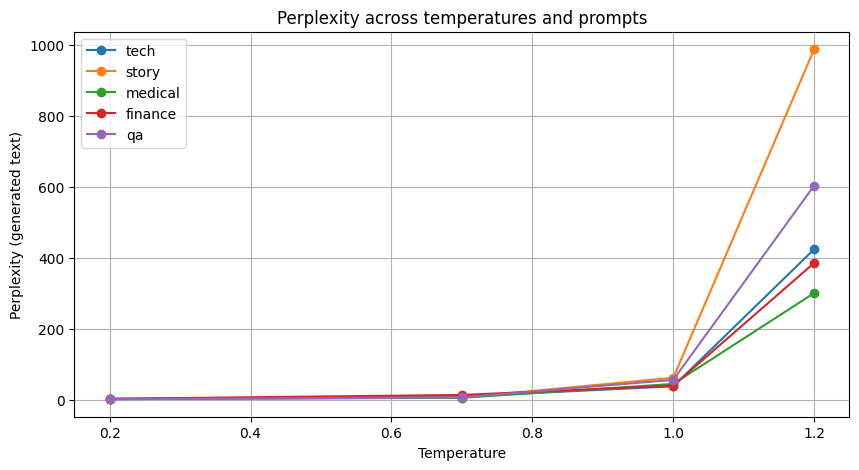

In [21]:
# CELL: Plot perplexity by prompt and temperature
import matplotlib.pyplot as plt

# organize data
prompt_names = list(prompts.keys())
temp_vals = sorted(list(set([r['temperature'] for r in experiment_results])))
ppl_matrix = {p:[] for p in prompt_names}
d1_matrix = {p:[] for p in prompt_names}

for p in prompt_names:
    for t in temp_vals:
        # average across returned sequences for that config
        vals = [r for r in experiment_results if r['prompt']==p and r['temperature']==t]
        if vals:
            ppl_matrix[p].append(vals[0]['perplexity'])
            d1_matrix[p].append(vals[0]['distinct-1'])
        else:
            ppl_matrix[p].append(np.nan)
            d1_matrix[p].append(np.nan)

# plot
plt.figure(figsize=(10,5))
for p in prompt_names:
    plt.plot(temp_vals, ppl_matrix[p], marker='o', label=p)
plt.xlabel("Temperature")
plt.ylabel("Perplexity (generated text)")
plt.title("Perplexity across temperatures and prompts")
plt.legend()
plt.grid(True)
plt.show()


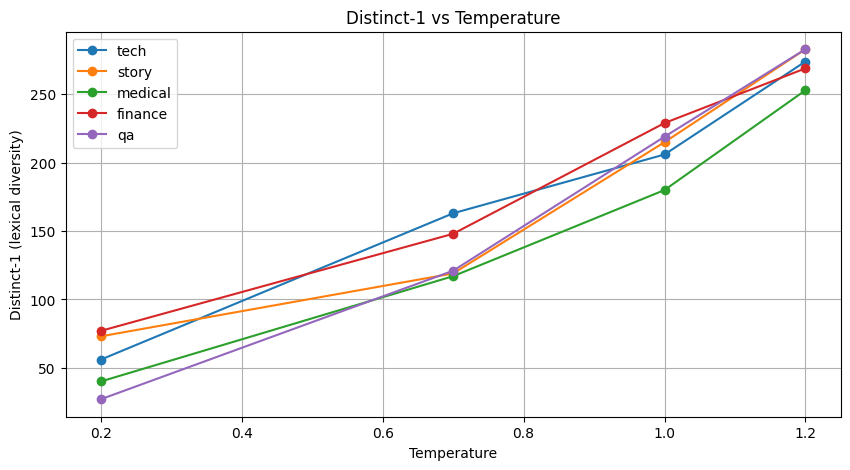

In [22]:
# CELL: Plot distinct-1 as proxy for lexical diversity
plt.figure(figsize=(10,5))
for p in prompt_names:
    plt.plot(temp_vals, d1_matrix[p], marker='o', label=p)
plt.xlabel("Temperature")
plt.ylabel("Distinct-1 (lexical diversity)")
plt.title("Distinct-1 vs Temperature")
plt.legend()
plt.grid(True)
plt.show()


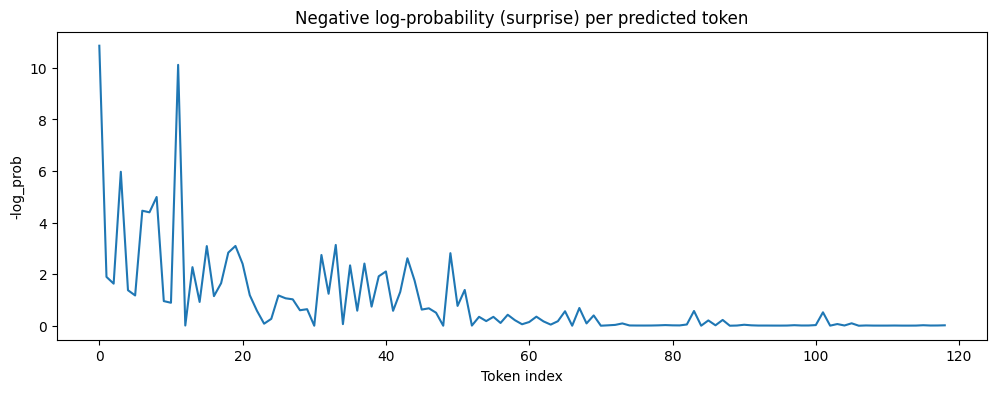

In [23]:
# CELL: token probability heatmap for one example
def token_probabilities(text):
    enc = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(enc.input_ids)
        logits = outputs.logits[0, :-1, :]   # (seq_len-1, vocab)
        next_token_ids = enc.input_ids[0,1:]
        token_logits = logits[range(len(next_token_ids)), next_token_ids]
        log_probs = torch.log_softmax(logits, dim=-1)
        token_log_probs = log_probs[range(len(next_token_ids)), next_token_ids].cpu().numpy()
        return tokenizer.convert_ids_to_tokens(next_token_ids.cpu().numpy()), token_log_probs

sample = experiment_results[0]['outputs'][0]
tokens, logps = token_probabilities(sample)
plt.figure(figsize=(12,4))
plt.plot(-logps)  # plot negative log-prob -> higher = less confident
plt.title("Negative log-probability (surprise) per predicted token")
plt.xlabel("Token index")
plt.ylabel("-log_prob")
plt.show()


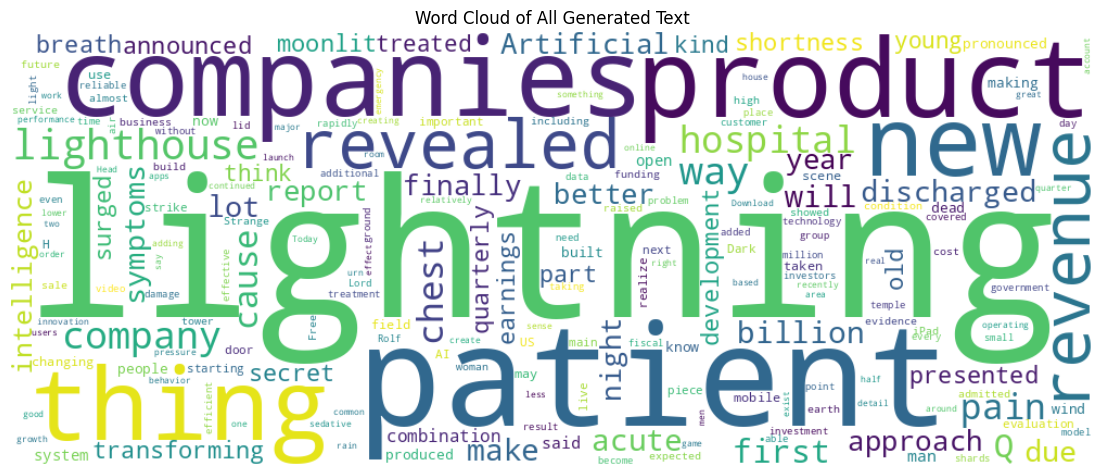

In [24]:
# CELL: wordcloud
all_generated = " ".join([o for r in experiment_results for o in r['outputs']])
wc = WordCloud(width=1000, height=400, background_color='white', collocations=False).generate(all_generated)
plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of All Generated Text")
plt.show()


In [25]:
# CELL: Save results JSON for reporting
os.makedirs("results", exist_ok=True)
with open("results/experiment_results.json", "w") as f:
    json.dump(experiment_results, f, indent=2)
print("Saved results/experiment_results.json")


Saved results/experiment_results.json
